# Mental Health Text Classification — Team MARS
### CSS 324 · 7-class mental health disorder detection from social media text
**Models:** TF-IDF baselines · SBERT · MentalBERT · Combined embeddings · Fine-tune MentalBERT  
**Goal:** Maximize Macro F1 with hard constraints: Suicidal Recall ≥ 0.90, Depression Recall ≥ 0.85

## 0. Install Dependencies

In [1]:
# Run once, then comment out
# !pip install vaderSentiment textblob empath wordcloud
# !pip install lightgbm catboost xgboost
# !pip install sentence-transformers
# !pip install imbalanced-learn shap
# !pip install transformers accelerate datasets huggingface_hub
# !python -m nltk.downloader punkt punkt_tab stopwords wordnet

## 1. Imports & Config

In [2]:
import os, re, time, warnings, unicodedata, joblib
import numpy as np
import pandas as pd
from collections import Counter
from scipy import sparse

import matplotlib.pyplot as plt
import seaborn as sns
import nltk
for pkg in ["punkt", "punkt_tab", "stopwords", "wordnet"]:
    nltk.download(pkg, quiet=True)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score, roc_auc_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.utils.class_weight import compute_class_weight

from imblearn.over_sampling import SMOTE

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("husl")

# ── Config ────────────────────────────────────────────────────────────────────
SEED   = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps"
                       if torch.backends.mps.is_available() else "cpu")

VALID_LABELS   = ["Normal", "Depression", "Suicidal", "Anxiety",
                   "Stress", "Bipolar", "Personality Disorder"]
HIGH_RISK      = ["Suicidal", "Depression"]
RECALL_TARGET  = {"Suicidal": 0.90, "Depression": 0.85}

# Storage for all trained models and results
trained     = {}
leaderboard = {}

print(f"Device: {DEVICE} | CUDA: {torch.cuda.is_available()}")

Device: cuda | CUDA: True


## 2. Data Loading

In [3]:
df_raw = pd.read_csv("Combined Data.csv")
df_raw = df_raw.drop(columns=[c for c in df_raw.columns
                               if c.startswith("Unnamed")], errors="ignore")

# Standardise column names
LABEL_MAP = {
    "Normal": "Normal", "Depression": "Depression", "Suicidal": "Suicidal",
    "Anxiety": "Anxiety", "Stress": "Stress", "Bipolar": "Bipolar",
    "Personality disorder": "Personality Disorder",
    "Personality Disorder": "Personality Disorder",
}
tcol = next(c for c in df_raw.columns if "statement" in c.lower() or "text" in c.lower())
lcol = next(c for c in df_raw.columns if "status" in c.lower() or "label" in c.lower())

df = pd.DataFrame({
    "text":  df_raw[tcol].astype(str),
    "label": df_raw[lcol].astype(str).str.strip().map(LABEL_MAP),
}).dropna(subset=["label"]).reset_index(drop=True)

print(f"Shape: {df.shape}")
print(df["label"].value_counts().to_string())

Shape: (53043, 2)
label
Normal                  16351
Depression              15404
Suicidal                10653
Anxiety                  3888
Bipolar                  2877
Stress                   2669
Personality Disorder     1201


## 3. EDA — Class Distribution & Text Length

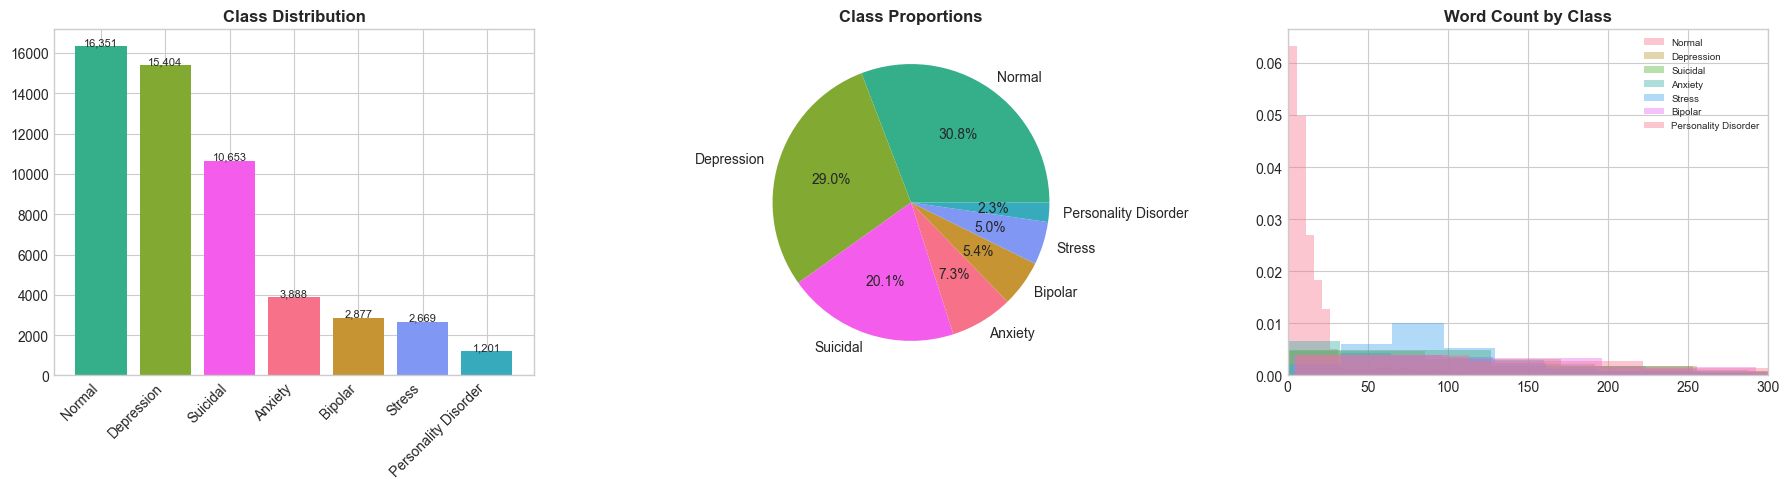


Imbalance ratios:
  Normal                    16,351  (13.6x)
  Depression                15,404  (12.8x)
  Suicidal                  10,653  (8.9x)
  Anxiety                    3,888  (3.2x)
  Bipolar                    2,877  (2.4x)
  Stress                     2,669  (2.2x)
  Personality Disorder       1,201  (1.0x)


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cc = df["label"].value_counts()
PALETTE = dict(zip(sorted(df["label"].unique()),
                   sns.color_palette("husl", df["label"].nunique())))

# Bar chart
axes[0].bar(range(len(cc)), cc.values,
            color=[PALETTE.get(c, "gray") for c in cc.index])
axes[0].set_xticks(range(len(cc)))
axes[0].set_xticklabels(cc.index, rotation=45, ha="right")
axes[0].set_title("Class Distribution", fontweight="bold")
for i, v in enumerate(cc.values):
    axes[0].text(i, v + 50, f"{v:,}", ha="center", fontsize=8)

# Pie chart
axes[1].pie(cc.values, labels=cc.index, autopct="%1.1f%%",
            colors=[PALETTE.get(c, "gray") for c in cc.index])
axes[1].set_title("Class Proportions", fontweight="bold")

# Word count distribution
df["_wc"] = df["text"].str.split().str.len()
for cls in VALID_LABELS:
    sub = df[df["label"] == cls]["_wc"]
    axes[2].hist(sub, bins=50, alpha=0.4, label=cls, density=True)
axes[2].set_xlim(0, 300)
axes[2].set_title("Word Count by Class", fontweight="bold")
axes[2].legend(fontsize=7)
df.drop(columns=["_wc"], inplace=True)

plt.tight_layout()
plt.show()

# Imbalance ratio
print("\nImbalance ratios:")
for cls, cnt in cc.items():
    print(f"  {cls:25s} {cnt:6,}  ({cnt/cc.min():.1f}x)")

## 4. Text Cleaning Pipeline (8 steps)

In [5]:
from nltk.tokenize import sent_tokenize
from nltk.corpus import stopwords
SW = set(stopwords.words("english"))

cleaning_log = []

def log_step(df_curr, name):
    n = len(df_curr)
    avg = df_curr["text"].str.len().mean()
    cleaning_log.append({"step": name, "rows": n, "avg_chars": round(avg, 1)})
    print(f"  {name:45s} -> {n:,} rows | avg {avg:.0f} chars")

log_step(df, "0. Raw")

# 1. Exact duplicates
df = df.drop_duplicates(subset=["text"], keep="first")
log_step(df, "1. Remove exact duplicates")

# 2. Null / empty
df["text"] = df["text"].fillna("")
df = df[df["text"].str.strip().str.len() > 0]
log_step(df, "2. Remove null/empty")

# 3. Reddit artifacts (subreddit names = label leakage)
def clean_reddit(t):
    if not isinstance(t, str): return ""
    if t.strip().lower() in ["[deleted]", "[removed]", "nan", "none", ""]: return ""
    t = re.sub(r"\[([^\]]+)\]\([^)]+\)", r"\1", t)
    t = re.sub(r"/?r/\w+", "", t)
    t = re.sub(r"/?u/\w+", "", t)
    t = re.sub(r"&gt;.*?(?:\n|$)", "", t)
    t = re.sub(r"\*{1,2}(.+?)\*{1,2}", r"\1", t)
    return t

df["text"] = df["text"].apply(clean_reddit)
df = df[df["text"].str.strip().str.len() > 0]
log_step(df, "3. Remove Reddit artifacts")

# 4. HTML / URL / email
def clean_html(t):
    if not isinstance(t, str): return ""
    t = re.sub(r"<[^>]+>", " ", t)
    t = re.sub(r"&amp;", "and", t)
    t = re.sub(r"&\w+;|&#\d+;", " ", t)
    t = re.sub(r"https?://\S+|www\.\S+", " ", t)
    t = re.sub(r"\S+@\S+\.\S+", " ", t)
    return t

df["text"] = df["text"].apply(clean_html)
log_step(df, "4. Remove HTML/URL/email")

# 5. Unicode normalization + emoji removal
def norm_unicode(t):
    if not isinstance(t, str): return ""
    t = unicodedata.normalize("NFC", t)
    for old, new in [("\u2018","'"),("\u2019","'"),("\u201c",'"'),
                     ("\u201d",'"'),("\u2013","-"),("\u2014","-"),
                     ("\u2026","..."),("\xa0"," ")]:
        t = t.replace(old, new)
    t = re.sub(r"[\U0001F600-\U0001F64F\U0001F300-\U0001F5FF"
               r"\U0001F680-\U0001F6FF\U0001F1E0-\U0001F1FF"
               r"\U00002702-\U000027B0\U00010000-\U0010FFFF]+", " ", t)
    return t

df["text"] = df["text"].apply(norm_unicode)
log_step(df, "5. Normalize Unicode/emoji")

# 6. Special chars + whitespace
def clean_chars(t):
    if not isinstance(t, str): return ""
    t = re.sub(r"[^\w\s.,!?;:'\"\-]", " ", t)
    t = re.sub(r"\b\d+\b", " ", t)
    t = re.sub(r"\s+", " ", t).strip()
    t = re.sub(r"([!?.])\1{2,}", r"\1", t)
    t = re.sub(r"(.)\1{2,}", r"\1\1", t)
    return t

df["text"] = df["text"].apply(clean_chars)
log_step(df, "6. Clean special chars")

# 7. Remove short posts (< 5 words)
df["_wc"] = df["text"].str.split().str.len()
df = df[df["_wc"] >= 5].drop(columns=["_wc"])
log_step(df, "7. Remove short posts (< 5 words)")

# 8. Validate labels
df["label"] = df["label"].str.strip().str.title()
df["label"] = df["label"].replace({"Personality disorder": "Personality Disorder"})
df = df[df["label"].isin(VALID_LABELS)].reset_index(drop=True)
log_step(df, "8. Validate labels")

removed = cleaning_log[0]["rows"] - cleaning_log[-1]["rows"]
print(f"\nRemoved: {removed:,} rows | Final: {len(df):,} rows")
df.to_csv("mh_clean.csv", index=False)

  0. Raw                                        -> 53,043 rows | avg 579 chars
  1. Remove exact duplicates                    -> 51,074 rows | avg 575 chars
  2. Remove null/empty                          -> 51,073 rows | avg 575 chars
  3. Remove Reddit artifacts                    -> 51,069 rows | avg 574 chars
  4. Remove HTML/URL/email                      -> 51,069 rows | avg 573 chars
  5. Normalize Unicode/emoji                    -> 51,069 rows | avg 573 chars
  6. Clean special chars                        -> 51,069 rows | avg 569 chars
  7. Remove short posts (< 5 words)             -> 48,293 rows | avg 601 chars
  8. Validate labels                            -> 48,293 rows | avg 601 chars

Removed: 4,750 rows | Final: 48,293 rows


## 5. Feature Engineering

In [6]:
df = pd.read_csv("mh_clean.csv")
df["text_lower"] = df["text"].str.lower()

# ── Label encoding ────────────────────────────────────────────────────────────
le = LabelEncoder()
le.fit(VALID_LABELS)
y_all  = le.transform(df["label"])
CLASSES = list(le.classes_)
print(f"Classes: {CLASSES}")

# ── TF-IDF ────────────────────────────────────────────────────────────────────
tfidf = TfidfVectorizer(
    max_features=20000, ngram_range=(1, 2), sublinear_tf=True,
    min_df=2, max_df=0.95, strip_accents="unicode", dtype=np.float32,
)
X_tfidf = tfidf.fit_transform(df["text_lower"])
print(f"TF-IDF shape: {X_tfidf.shape}")

Classes: [np.str_('Anxiety'), np.str_('Bipolar'), np.str_('Depression'), np.str_('Normal'), np.str_('Personality Disorder'), np.str_('Stress'), np.str_('Suicidal')]
TF-IDF shape: (48293, 20000)


In [7]:
# ── VADER + TextBlob sentiment ───────────────────────────────────────────────
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob

sia = SentimentIntensityAnalyzer()
scores = df["text"].apply(lambda t: sia.polarity_scores(str(t)))
df["vader_neg"]       = scores.apply(lambda x: x["neg"])
df["vader_neu"]       = scores.apply(lambda x: x["neu"])
df["vader_pos"]       = scores.apply(lambda x: x["pos"])
df["vader_compound"]  = scores.apply(lambda x: x["compound"])
df["tb_polarity"]     = df["text"].apply(lambda t: TextBlob(str(t)).sentiment.polarity)
df["tb_subjectivity"] = df["text"].apply(lambda t: TextBlob(str(t)).sentiment.subjectivity)
sentiment_cols = ["vader_neg","vader_neu","vader_pos","vader_compound",
                  "tb_polarity","tb_subjectivity"]
print(f"Sentiment features: {len(sentiment_cols)}")

Sentiment features: 6


In [8]:
# ── Psycholinguistic features ─────────────────────────────────────────────────
SUICIDE_PHRASES = {
    "kill myself","end it","end my life","want to die","suicide","suicidal",
    "no reason to live","better off without me","goodbye","burden",
    "no other way","cant go on","dont want to be here","overdose",
    "take my life","not worth living","rather be dead","final goodbye",
}
FPS = {"i","me","my","myself","mine","im","i'm","i've","i'd","i'll"}
ABS = {"always","never","nothing","everything","completely","totally",
       "absolutely","entirely","constantly","definitely","impossible",
       "forever","nobody","nowhere","worst","perfect"}
NEG = {"not","no","never","neither","nobody","nothing","nowhere","nor",
       "cannot","can't","won't","don't","doesn't","didn't","isn't",
       "aren't","wasn't","weren't","shouldn't","wouldn't","couldn't",
       "haven't","hasn't","hadn't"}

def token_ratio(text, wordset):
    w = str(text).lower().split()
    return sum(1 for x in w if x in wordset) / max(len(w), 1)

def count_suicide_phrases(text):
    t = str(text).lower()
    return sum(1 for phrase in SUICIDE_PHRASES if phrase in t)

df["first_person_ratio"] = df["text"].apply(lambda t: token_ratio(t, FPS))
df["absolutist_ratio"]   = df["text"].apply(lambda t: token_ratio(t, ABS))
df["negation_ratio"]     = df["text"].apply(lambda t: token_ratio(t, NEG))
df["suicide_lexicon"]    = df["text"].apply(count_suicide_phrases)
psych_cols = ["first_person_ratio","absolutist_ratio","negation_ratio","suicide_lexicon"]
print(f"Psycholinguistic features: {len(psych_cols)}")

Psycholinguistic features: 4


In [9]:
# ── Statistical features ──────────────────────────────────────────────────────
def text_stats(t):
    t = str(t)
    words = t.split()
    wc = max(len(words), 1)
    try:
        sc = max(len(sent_tokenize(t)), 1)
    except Exception:
        sc = max(t.count(".") + 1, 1)
    return {
        "char_count":        len(t),
        "word_count":        wc,
        "sentence_count":    sc,
        "avg_word_len":      np.mean([len(w) for w in words]) if words else 0,
        "avg_sentence_len":  wc / sc,
        "lexical_diversity": len({w.lower() for w in words}) / wc,
        "exclamation_count": t.count("!"),
        "question_count":    t.count("?"),
        "uppercase_ratio":   sum(c.isupper() for c in t) / max(len(t), 1),
        "stopword_ratio":    sum(w.lower() in SW for w in words) / wc,
    }

ts = df["text"].apply(text_stats)
stat_cols = list(ts.iloc[0].keys())
for c in stat_cols:
    df[c] = ts.apply(lambda x: x[c])
print(f"Statistical features: {len(stat_cols)}")

Statistical features: 10


In [10]:
# ── Empath features ──────────────────────────────────────────────────────────
empath_cols = []
try:
    from empath import Empath
    lex = Empath()
    CATS = ["sadness","negative_emotion","positive_emotion","death","pain",
            "suffering","sleep","health","anger","fear","anxiety","optimism",
            "shame","love","hate","violence","nervousness","help","sympathy",
            "swearing_terms"]
    esc = df["text"].apply(
        lambda t: lex.analyze(str(t), categories=CATS, normalize=True) or {c: 0 for c in CATS}
    )
    for c in CATS:
        df[f"empath_{c}"] = esc.apply(lambda x: x.get(c, 0.0))
    empath_cols = [f"empath_{c}" for c in CATS]
    print(f"Empath features: {len(empath_cols)}")
except ImportError:
    print("Empath not installed — skipping. pip install empath")

Empath features: 20


In [11]:
# ── LDA topics ────────────────────────────────────────────────────────────────
N_TOPICS = 15
cvec = CountVectorizer(max_features=5000, max_df=0.95, min_df=3, stop_words="english")
X_counts = cvec.fit_transform(df["text_lower"])
lda = LatentDirichletAllocation(
    n_components=N_TOPICS, random_state=SEED,
    n_jobs=-1, learning_method="online", max_iter=10
)
X_lda = lda.fit_transform(X_counts)
lda_cols = [f"topic_{i}" for i in range(N_TOPICS)]
for i, c in enumerate(lda_cols):
    df[c] = X_lda[:, i]
print(f"LDA topics: {X_lda.shape}")

LDA topics: (48293, 15)


In [12]:
# ── Combine all numeric features ─────────────────────────────────────────────
num_feat_cols = sentiment_cols + psych_cols + stat_cols + empath_cols + lda_cols
stat_feats    = num_feat_cols  # alias used in SHAP section

scaler   = StandardScaler()
num_data = df[num_feat_cols].fillna(0).values.astype(np.float32)

# Save features for binary classifier
df[num_feat_cols].to_csv("mh_features.csv", index=False)
print(f"Saved mh_features.csv | Numeric features: {len(num_feat_cols)}")

Saved mh_features.csv | Numeric features: 55


## 6. Train / Val / Test Split

In [13]:
texts = df["text"].to_numpy(dtype=object)
labels = y_all

# 70 / 15 / 15 stratified split
X_train_text, X_temp_text, y_train, y_temp = train_test_split(
    texts, labels, test_size=0.30, random_state=SEED, stratify=labels)
X_val_text, X_test_text, y_val, y_test = train_test_split(
    X_temp_text, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp)

# TF-IDF splits
idx_train = np.where(np.isin(texts, X_train_text))[0][:len(X_train_text)]
# Proper index-based split
all_idx = np.arange(len(df))
idx_tr, idx_temp = train_test_split(all_idx, test_size=0.30,
                                     random_state=SEED, stratify=labels)
idx_val, idx_te  = train_test_split(idx_temp, test_size=0.50,
                                     random_state=SEED, stratify=labels[idx_temp])

X_train_text = texts[idx_tr]
X_val_text   = texts[idx_val]
X_test_text  = texts[idx_te]
y_train      = labels[idx_tr]
y_val        = labels[idx_val]
y_test       = labels[idx_te]

# TF-IDF matrices
X_tfidf_train = tfidf.transform(df["text_lower"].values[idx_tr])
X_tfidf_val   = tfidf.transform(df["text_lower"].values[idx_val])
X_tfidf_test  = tfidf.transform(df["text_lower"].values[idx_te])

# Numeric features — fit scaler on train only
num_train = scaler.fit_transform(num_data[idx_tr])
num_val   = scaler.transform(num_data[idx_val])
num_test  = scaler.transform(num_data[idx_te])

# Combined sparse: TF-IDF + numeric
X_combo_train = sparse.hstack([X_tfidf_train, sparse.csr_matrix(num_train)], format="csr")
X_combo_val   = sparse.hstack([X_tfidf_val,   sparse.csr_matrix(num_val)],   format="csr")
X_combo_test  = sparse.hstack([X_tfidf_test,  sparse.csr_matrix(num_test)],  format="csr")

print(f"Train: {len(y_train):,} | Val: {len(y_val):,} | Test: {len(y_test):,}")
print(f"X_combo shape: {X_combo_train.shape}")

# Class weights for imbalanced training
cw = compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
cw_dict = dict(enumerate(cw))
ce_weights = torch.tensor(cw, dtype=torch.float32).to(DEVICE)

Train: 33,805 | Val: 7,244 | Test: 7,244
X_combo shape: (33805, 20055)


## 7. Evaluation Function & Confusion Matrix Helper

In [14]:
def evaluate(name, y_true, y_pred, proba=None, verbose=True):
    """Compute all metrics and store in leaderboard."""
    macro_f1    = f1_score(y_true, y_pred, average="macro",     zero_division=0)
    weighted_f1 = f1_score(y_true, y_pred, average="weighted",  zero_division=0)
    acc         = accuracy_score(y_true, y_pred)

    roc_auc = None
    if proba is not None:
        try:
            roc_auc = roc_auc_score(y_true, proba, multi_class="ovr", average="macro")
        except Exception:
            pass

    cm      = confusion_matrix(y_true, y_pred)
    sui_i   = CLASSES.index("Suicidal")
    dep_i   = CLASSES.index("Depression")
    sui_rec = cm[sui_i, sui_i] / cm[sui_i].sum() if cm[sui_i].sum() > 0 else 0
    dep_rec = cm[dep_i, dep_i] / cm[dep_i].sum() if cm[dep_i].sum() > 0 else 0

    sui_ok = "OK" if sui_rec >= RECALL_TARGET["Suicidal"]   else "FAIL"
    dep_ok = "OK" if dep_rec >= RECALL_TARGET["Depression"] else "FAIL"

    if verbose:
        print(f"{'='*55}")
        print(f"  {name}")
        print(f"  Macro F1:     {macro_f1:.4f}")
        print(f"  Weighted F1:  {weighted_f1:.4f}")
        print(f"  Accuracy:     {acc:.4f}")
        if roc_auc:
            print(f"  ROC AUC:      {roc_auc:.4f}")
        print(f"  Suicidal R:   {sui_rec:.4f}  [{sui_ok}]  (target >= {RECALL_TARGET['Suicidal']})")
        print(f"  Depression R: {dep_rec:.4f}  [{dep_ok}]  (target >= {RECALL_TARGET['Depression']})")

    leaderboard[name] = {
        "Macro F1":    round(macro_f1,    4),
        "Weighted F1": round(weighted_f1, 4),
        "Accuracy":    round(acc,         4),
        "ROC AUC":     round(roc_auc, 4) if roc_auc else None,
        "Suicidal R":  round(sui_rec,     4),
        "Depress R":   round(dep_rec,     4),
        "Sui OK":      sui_ok,
        "Dep OK":      dep_ok,
    }
    return macro_f1


def plot_cm(y_true, y_pred, title):
    cm  = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(9, 7))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES)
    disp.plot(ax=ax, colorbar=False, cmap="Blues",
              xticks_rotation=45, values_format="d")
    ax.set_title(title, fontweight="bold")
    plt.tight_layout()
    plt.show()


print("evaluate() and plot_cm() ready")

evaluate() and plot_cm() ready


## 8. SBERT Embeddings (MiniLM-L6-v2, 384d)

In [15]:
SBERT_TRAIN = "sbert_train.npy"
SBERT_VAL   = "sbert_val.npy"
SBERT_TEST  = "sbert_test.npy"
HAS_SBERT   = False

try:
    from sentence_transformers import SentenceTransformer
    sbert = SentenceTransformer("all-MiniLM-L6-v2")

    if all(os.path.exists(p) for p in [SBERT_TRAIN, SBERT_VAL, SBERT_TEST]):
        emb_train = np.load(SBERT_TRAIN)
        emb_val   = np.load(SBERT_VAL)
        emb_test  = np.load(SBERT_TEST)
        print(f"Loaded cached SBERT embeddings. Shape: {emb_train.shape}")
    else:
        def sbert_encode(texts, bs=128):
            return sbert.encode(texts.tolist(), batch_size=bs,
                                show_progress_bar=True,
                                convert_to_numpy=True,
                                normalize_embeddings=True).astype(np.float32)
        print("Encoding SBERT...")
        emb_train = sbert_encode(X_train_text)
        emb_val   = sbert_encode(X_val_text)
        emb_test  = sbert_encode(X_test_text)
        np.save(SBERT_TRAIN, emb_train)
        np.save(SBERT_VAL,   emb_val)
        np.save(SBERT_TEST,  emb_test)
        print(f"Saved. Shape: {emb_train.shape}")

    # SMOTE on SBERT
    smote = SMOTE(random_state=SEED, k_neighbors=3)
    emb_train_bal, y_train_bal = smote.fit_resample(emb_train, y_train)
    print(f"After SMOTE: {len(emb_train)} -> {len(emb_train_bal)}")
    HAS_SBERT = True

except ImportError:
    print("sentence-transformers not installed. pip install sentence-transformers")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 5656.40it/s]


Loaded cached SBERT embeddings. Shape: (33805, 384)
After SMOTE: 33805 -> 73542


## 9. MentalBERT Embeddings (768d)

In [ ]:
from transformers import AutoTokenizer, AutoModel
from huggingface_hub import login

login(token="YOUR_HF_TOKEN")  # вставь свой токен локально

MENTAL_TRAIN = "mental_train.npy"
MENTAL_VAL   = "mental_val.npy"
MENTAL_TEST  = "mental_test.npy"
HAS_MENTAL   = False


try:

    MENTAL_NAME = "mental/mental-bert-base-uncased"
    tok_mental  = AutoTokenizer.from_pretrained(MENTAL_NAME)
    mod_mental  = AutoModel.from_pretrained(MENTAL_NAME).to(DEVICE).eval()

    def mean_pool(token_emb, attention_mask):
        mask = attention_mask.unsqueeze(-1).expand(token_emb.size()).float()
        return (token_emb * mask).sum(1) / mask.sum(1).clamp(min=1e-9)

    def encode_mental(texts, bs=32):
        all_emb = []
        for i in range(0, len(texts), bs):
            batch = texts[i:i+bs].tolist()
            enc   = tok_mental(batch, truncation=True, padding=True,
                               max_length=256, return_tensors="pt")
            enc   = {k: v.to(DEVICE) for k, v in enc.items()}
            with torch.no_grad():
                out = mod_mental(**enc)
            emb = mean_pool(out.last_hidden_state, enc["attention_mask"])
            all_emb.append(emb.cpu().numpy())
            if i % (bs * 10) == 0:
                print(f"  {i}/{len(texts)}", end="\r")
        return np.vstack(all_emb).astype(np.float32)

    if all(os.path.exists(p) for p in [MENTAL_TRAIN, MENTAL_VAL, MENTAL_TEST]):
        mental_train = np.load(MENTAL_TRAIN)
        mental_val   = np.load(MENTAL_VAL)
        mental_test  = np.load(MENTAL_TEST)
        print(f"Loaded cached MentalBERT. Shape: {mental_train.shape}")
    else:
        print("Encoding MentalBERT (this takes ~10-15 min on CPU)...")
        mental_train = encode_mental(X_train_text)
        mental_val   = encode_mental(X_val_text)
        mental_test  = encode_mental(X_test_text)
        np.save(MENTAL_TRAIN, mental_train)
        np.save(MENTAL_VAL,   mental_val)
        np.save(MENTAL_TEST,  mental_test)
        print(f"Saved. Shape: {mental_train.shape}")

    smote_m = SMOTE(random_state=SEED, k_neighbors=3)
    mental_train_bal, y_mental_bal = smote_m.fit_resample(mental_train, y_train)
    print(f"After SMOTE: {len(mental_train)} -> {len(mental_train_bal)}")
    HAS_MENTAL = True

except Exception as e:
    print(f"MentalBERT unavailable: {e}")

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 30092.43it/s]
[transformers] BertModel LOAD REPORT from: mental/mental-bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
pooler.dense.bias                          | MISSING    | 
pooler.dense.weight                        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. C

Encoding MentalBERT (this takes ~10-15 min on CPU)...
Saved. Shape: (33805, 768)
After SMOTE: 33805 -> 73542


## 10. Combined Embeddings (MiniLM + MentalBERT = 1152d)

In [17]:
HAS_COMBO = False
if HAS_SBERT and HAS_MENTAL:
    combo_train = np.hstack([emb_train, mental_train])
    combo_val   = np.hstack([emb_val,   mental_val])
    combo_test  = np.hstack([emb_test,  mental_test])

    smote_c = SMOTE(random_state=SEED, k_neighbors=3)
    combo_train_bal, y_combo_bal = smote_c.fit_resample(combo_train, y_train)
    print(f"Combined dim: {combo_train.shape[1]} | After SMOTE: {len(combo_train_bal)}")
    HAS_COMBO = True
else:
    print("Skipped — need both SBERT and MentalBERT")

Combined dim: 1152 | After SMOTE: 73542


## 11. Neural Network Architectures

In [18]:
class EmbDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(np.asarray(X), dtype=torch.float32)
        self.y = torch.tensor(np.asarray(y), dtype=torch.long)
    def __len__(self):  return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]


class MLPShallow(nn.Module):
    """Shallow MLP: input -> 512 -> 256 -> 128 -> n_classes"""
    def __init__(self, in_dim, n_classes, dropout=0.4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(512, 256),    nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(256, 128),    nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(dropout * 0.5),
            nn.Linear(128, n_classes)
        )
    def forward(self, x): return self.net(x)


class MLPDeep(nn.Module):
    """Deep MLP: input -> 768 -> 512 -> 256 -> 128 -> 64 -> n_classes"""
    def __init__(self, in_dim, n_classes, dropout=0.4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 768), nn.BatchNorm1d(768), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(768, 512),    nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(512, 256),    nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(256, 128),    nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(dropout * 0.5),
            nn.Linear(128, 64),     nn.BatchNorm1d(64),  nn.ReLU(), nn.Dropout(dropout * 0.5),
            nn.Linear(64, n_classes)
        )
    def forward(self, x): return self.net(x)


class CNN1D(nn.Module):
    """1D-CNN over embedding features.
    Treats embedding dims as channels, applies Conv1D across a small kernel.
    Works well on dense embeddings as a feature extractor.
    """
    def __init__(self, in_dim, n_classes, dropout=0.4):
        super().__init__()
        # Reshape: (batch, in_dim) -> (batch, 1, in_dim) for Conv1d
        self.conv1 = nn.Conv1d(1, 128, kernel_size=5, padding=2)
        self.conv2 = nn.Conv1d(128, 256, kernel_size=3, padding=1)
        self.pool  = nn.AdaptiveMaxPool1d(32)  # global-ish pooling
        self.fc    = nn.Sequential(
            nn.Linear(256 * 32, 256), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(256, n_classes)
        )
    def forward(self, x):
        x = x.unsqueeze(1)           # (B, 1, D)
        x = F.relu(self.conv1(x))    # (B, 128, D)
        x = F.relu(self.conv2(x))    # (B, 256, D)
        x = self.pool(x)             # (B, 256, 32)
        x = x.flatten(1)             # (B, 256*32)
        return self.fc(x)


def train_nn(model, X_tr, y_tr, X_val, y_val,
             epochs=30, bs=256, lr=1e-3, patience=5):
    """Generic training loop for MLP / CNN models."""
    model.to(DEVICE)
    opt   = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    loss_fn = nn.CrossEntropyLoss(weight=ce_weights, label_smoothing=0.1)

    tr_ds  = EmbDataset(X_tr, y_tr)
    val_ds = EmbDataset(X_val, y_val)
    tr_dl  = DataLoader(tr_ds, batch_size=bs, shuffle=True,  num_workers=0)
    val_dl = DataLoader(val_ds,batch_size=bs, shuffle=False, num_workers=0)

    best_f1, patience_cnt, best_state = 0, 0, None

    for ep in range(1, epochs + 1):
        model.train()
        for Xb, yb in tr_dl:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            loss_fn(model(Xb), yb).backward()
            opt.step()
        sched.step()

        model.eval()
        preds = []
        with torch.no_grad():
            for Xb, _ in val_dl:
                preds.append(model(Xb.to(DEVICE)).argmax(1).cpu().numpy())
        val_f1 = f1_score(y_val, np.concatenate(preds), average="macro", zero_division=0)

        if val_f1 > best_f1:
            best_f1, patience_cnt = val_f1, 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_cnt += 1
            if patience_cnt >= patience:
                print(f"    Early stop at epoch {ep} | best val F1: {best_f1:.4f}")
                break

        if ep % 5 == 0:
            print(f"    Epoch {ep:3d} | val macro F1: {val_f1:.4f}")

    if best_state:
        model.load_state_dict(best_state)
    return model


def predict_nn(model, X, bs=256):
    model.eval()
    ds = EmbDataset(X, np.zeros(len(X)))
    dl = DataLoader(ds, batch_size=bs, shuffle=False, num_workers=0)
    preds, probas = [], []
    with torch.no_grad():
        for Xb, _ in dl:
            logits = model(Xb.to(DEVICE))
            probas.append(F.softmax(logits, dim=1).cpu().numpy())
            preds.append(logits.argmax(1).cpu().numpy())
    return np.concatenate(preds), np.vstack(probas)


print("Neural network classes and helpers ready")

Neural network classes and helpers ready


## 12. Classical Models — TF-IDF + Numeric Features

  LogReg (TF-IDF)
  Macro F1:     0.6972
  Weighted F1:  0.7438
  Accuracy:     0.7421
  ROC AUC:      0.9491
  Suicidal R:   0.7222  [FAIL]  (target >= 0.9)
  Depression R: 0.6037  [FAIL]  (target >= 0.85)


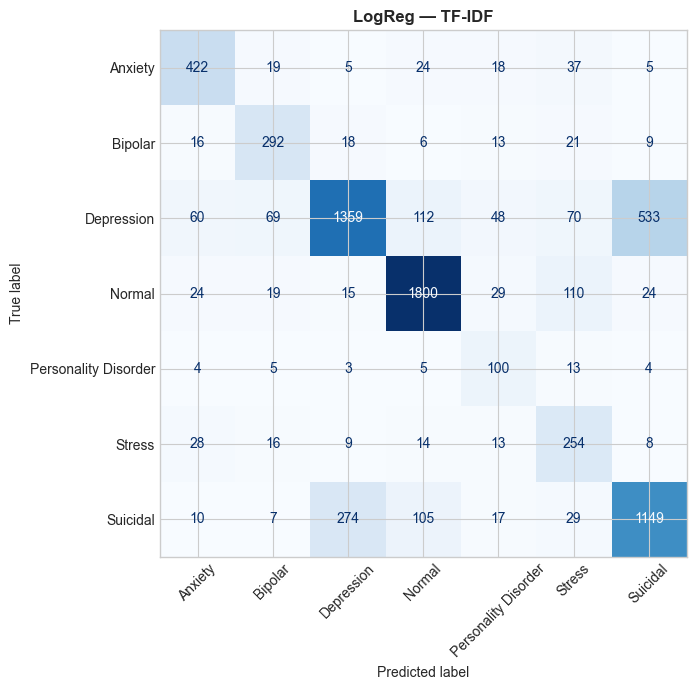

In [19]:
# ── Logistic Regression (baseline) ───────────────────────────────────────────
lr_model = LogisticRegression(
    C=1.0, random_state=SEED, max_iter=2000,
    solver="saga", class_weight="balanced", n_jobs=-1
)
lr_model.fit(X_combo_train, y_train)
trained["LogReg (TF-IDF)"] = lr_model
proba_lr = lr_model.predict_proba(X_combo_test)
evaluate("LogReg (TF-IDF)", y_test, lr_model.predict(X_combo_test), proba_lr)
plot_cm(y_test, lr_model.predict(X_combo_test), "LogReg — TF-IDF")

In [20]:
# ── LinearSVM (calibrated for probabilities) ─────────────────────────────────
svm_model = CalibratedClassifierCV(
    LinearSVC(C=1.0, random_state=SEED, max_iter=2000, class_weight="balanced"),
    cv=3
)
svm_model.fit(X_combo_train, y_train)
trained["LinearSVM (TF-IDF)"] = svm_model
proba_svm = svm_model.predict_proba(X_combo_test)
evaluate("LinearSVM (TF-IDF)", y_test, svm_model.predict(X_combo_test), proba_svm)

  LinearSVM (TF-IDF)
  Macro F1:     0.7242
  Weighted F1:  0.7641
  Accuracy:     0.7684
  ROC AUC:      0.9545
  Suicidal R:   0.6744  [FAIL]  (target >= 0.9)
  Depression R: 0.7450  [FAIL]  (target >= 0.85)


0.7241625217065255

Best C: {'estimator__C': 0.5} | CV F1: 0.7289
  SVM Tuned (TF-IDF)
  Macro F1:     0.7287
  Weighted F1:  0.7692
  Accuracy:     0.7732
  ROC AUC:      0.9561
  Suicidal R:   0.6776  [FAIL]  (target >= 0.9)
  Depression R: 0.7499  [FAIL]  (target >= 0.85)


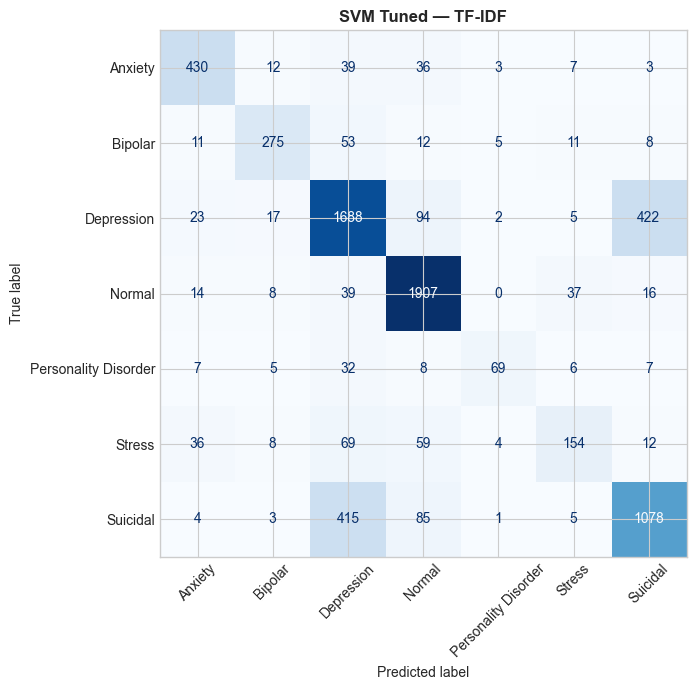

In [21]:
# ── SVM Tuned — GridSearch over C ────────────────────────────────────────────
cv_fold = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
gs = GridSearchCV(
    CalibratedClassifierCV(
        LinearSVC(random_state=SEED, max_iter=2000, class_weight="balanced"), cv=3),
    {"estimator__C": [0.1, 0.5, 1.0, 2.0, 5.0]},
    cv=cv_fold, scoring="f1_macro", n_jobs=-1, verbose=0
)
gs.fit(X_combo_train, y_train)
print(f"Best C: {gs.best_params_} | CV F1: {gs.best_score_:.4f}")
trained["SVM Tuned (TF-IDF)"] = gs
proba_svm_t = gs.predict_proba(X_combo_test)
evaluate("SVM Tuned (TF-IDF)", y_test, gs.predict(X_combo_test), proba_svm_t)
plot_cm(y_test, gs.predict(X_combo_test), "SVM Tuned — TF-IDF")

## 13. Gradient Boosting Models — SBERT 384d

[100]	valid_0's multi_logloss: 0.880958
[200]	valid_0's multi_logloss: 0.730269
[300]	valid_0's multi_logloss: 0.706285
  LightGBM (SBERT)
  Macro F1:     0.6819
  Weighted F1:  0.7326
  Accuracy:     0.7330
  ROC AUC:      0.9452
  Suicidal R:   0.6650  [FAIL]  (target >= 0.9)
  Depression R: 0.6415  [FAIL]  (target >= 0.85)


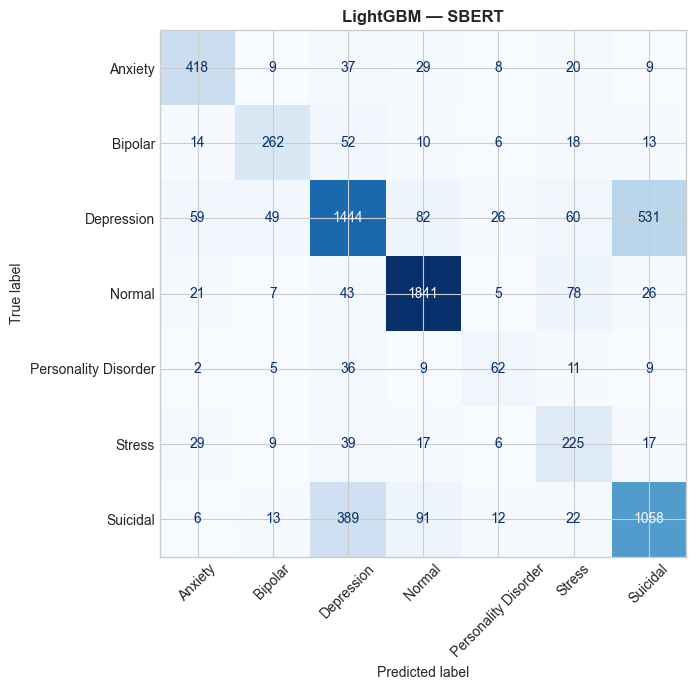

  CatBoost (SBERT)
  Macro F1:     0.6497
  Weighted F1:  0.7095
  Accuracy:     0.7076
  ROC AUC:      0.9375
  Suicidal R:   0.6317  [FAIL]  (target >= 0.9)
  Depression R: 0.5864  [FAIL]  (target >= 0.85)
  XGBoost (SBERT)
  Macro F1:     0.6841
  Weighted F1:  0.7327
  Accuracy:     0.7337
  ROC AUC:      0.9439
  Suicidal R:   0.6499  [FAIL]  (target >= 0.9)
  Depression R: 0.6517  [FAIL]  (target >= 0.85)


In [22]:
if HAS_SBERT:
    import lightgbm as lgb
    from catboost import CatBoostClassifier
    from xgboost import XGBClassifier

    lgb_params = {
        "objective": "multiclass", "num_class": len(CLASSES),
        "metric": "multi_logloss", "n_estimators": 500,
        "learning_rate": 0.05, "num_leaves": 63,
        "min_child_samples": 20, "subsample": 0.8,
        "colsample_bytree": 0.8, "reg_alpha": 0.1, "reg_lambda": 0.1,
        "class_weight": cw_dict, "random_state": SEED,
        "n_jobs": -1, "verbose": -1,
    }

    # LightGBM
    lgbm_s = lgb.LGBMClassifier(**lgb_params)
    lgbm_s.fit(emb_train_bal, y_train_bal,
               eval_set=[(emb_val, y_val)],
               callbacks=[lgb.early_stopping(50, verbose=False),
                          lgb.log_evaluation(100)])
    trained["LightGBM (SBERT)"] = lgbm_s
    evaluate("LightGBM (SBERT)", y_test,
             lgbm_s.predict(emb_test),
             lgbm_s.predict_proba(emb_test))
    plot_cm(y_test, lgbm_s.predict(emb_test), "LightGBM — SBERT")

    # CatBoost
    cb_s = CatBoostClassifier(random_seed=SEED, iterations=400,
                               learning_rate=0.05, depth=6,
                               auto_class_weights="Balanced", verbose=0)
    cb_s.fit(emb_train_bal, y_train_bal,
             eval_set=(emb_val, y_val),
             early_stopping_rounds=50)
    trained["CatBoost (SBERT)"] = cb_s
    evaluate("CatBoost (SBERT)", y_test,
             cb_s.predict(emb_test),
             cb_s.predict_proba(emb_test))

    # XGBoost
    xgb_s = XGBClassifier(
        random_state=SEED, n_estimators=300, learning_rate=0.05,
        max_depth=6, eval_metric="mlogloss", n_jobs=-1,
        use_label_encoder=False, verbosity=0
    )
    xgb_s.fit(emb_train_bal, y_train_bal,
              eval_set=[(emb_val, y_val)], verbose=0)
    trained["XGBoost (SBERT)"] = xgb_s
    evaluate("XGBoost (SBERT)", y_test,
             xgb_s.predict(emb_test),
             xgb_s.predict_proba(emb_test))

## 14. Stacking Ensemble — SBERT

  Stacking (SBERT)
  Macro F1:     0.6518
  Weighted F1:  0.7241
  Accuracy:     0.7322
  ROC AUC:      0.9176
  Suicidal R:   0.6003  [FAIL]  (target >= 0.9)
  Depression R: 0.7472  [FAIL]  (target >= 0.85)


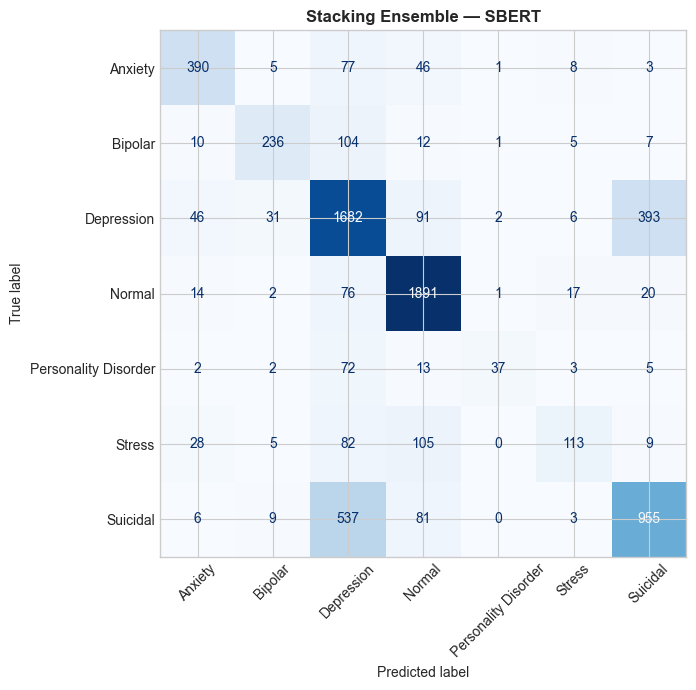

In [23]:
if HAS_SBERT:
    import lightgbm as lgb

    base_estimators = [
        ("lgbm", lgb.LGBMClassifier(**{**lgb_params, "n_estimators": 300, "verbose": -1})),
        ("rf",   RandomForestClassifier(n_estimators=200, class_weight=cw_dict,
                                        n_jobs=-1, random_state=SEED)),
        ("lr",   LogisticRegression(max_iter=500, C=1.0,
                                    class_weight="balanced",
                                    random_state=SEED, n_jobs=-1)),
    ]
    meta = LogisticRegression(max_iter=300, C=0.5, random_state=SEED)
    stack_s = StackingClassifier(
        estimators=base_estimators, final_estimator=meta,
        cv=5, stack_method="predict_proba", n_jobs=-1
    )
    stack_s.fit(emb_train_bal, y_train_bal)
    trained["Stacking (SBERT)"] = stack_s
    evaluate("Stacking (SBERT)", y_test,
             stack_s.predict(emb_test),
             stack_s.predict_proba(emb_test))
    plot_cm(y_test, stack_s.predict(emb_test), "Stacking Ensemble — SBERT")

## 15. Neural Networks — SBERT 384d

In [24]:
if HAS_SBERT:
    n_cls   = len(CLASSES)
    in_sbert = emb_train_bal.shape[1]

    # MLP Shallow
    print("Training MLP Shallow (SBERT)...")
    mlp_s = MLPShallow(in_sbert, n_cls)
    mlp_s = train_nn(mlp_s, emb_train_bal, y_train_bal, emb_val, y_val)
    trained["MLP Shallow (SBERT)"] = mlp_s
    preds, probas = predict_nn(mlp_s, emb_test)
    evaluate("MLP Shallow (SBERT)", y_test, preds, probas)

    # MLP Deep
    print("\nTraining MLP Deep (SBERT)...")
    mlp_ds = MLPDeep(in_sbert, n_cls)
    mlp_ds = train_nn(mlp_ds, emb_train_bal, y_train_bal, emb_val, y_val)
    trained["MLP Deep (SBERT)"] = mlp_ds
    preds, probas = predict_nn(mlp_ds, emb_test)
    evaluate("MLP Deep (SBERT)", y_test, preds, probas)

    # 1D-CNN
    print("\nTraining 1D-CNN (SBERT)...")
    cnn_s = CNN1D(in_sbert, n_cls)
    cnn_s = train_nn(cnn_s, emb_train_bal, y_train_bal, emb_val, y_val)
    trained["1D-CNN (SBERT)"] = cnn_s
    preds, probas = predict_nn(cnn_s, emb_test)
    evaluate("1D-CNN (SBERT)", y_test, preds, probas)

Training MLP Shallow (SBERT)...
    Epoch   5 | val macro F1: 0.6546
    Epoch  10 | val macro F1: 0.6870
    Epoch  15 | val macro F1: 0.7037
    Epoch  20 | val macro F1: 0.7099
    Early stop at epoch 23 | best val F1: 0.7139
  MLP Shallow (SBERT)
  Macro F1:     0.7060
  Weighted F1:  0.7485
  Accuracy:     0.7475
  ROC AUC:      0.9206
  Suicidal R:   0.7599  [FAIL]  (target >= 0.9)
  Depression R: 0.6015  [FAIL]  (target >= 0.85)

Training MLP Deep (SBERT)...
    Epoch   5 | val macro F1: 0.6479
    Epoch  10 | val macro F1: 0.6814
    Epoch  15 | val macro F1: 0.6935
    Epoch  20 | val macro F1: 0.7123
    Epoch  25 | val macro F1: 0.7201
    Epoch  30 | val macro F1: 0.7181
  MLP Deep (SBERT)
  Macro F1:     0.7154
  Weighted F1:  0.7505
  Accuracy:     0.7517
  ROC AUC:      0.9105
  Suicidal R:   0.7737  [FAIL]  (target >= 0.9)
  Depression R: 0.5993  [FAIL]  (target >= 0.85)

Training 1D-CNN (SBERT)...
    Epoch   5 | val macro F1: 0.5293
    Epoch  10 | val macro F1: 0.532

## 16. Gradient Boosting Models — MentalBERT 768d

[100]	valid_0's multi_logloss: 0.741762
[200]	valid_0's multi_logloss: 0.681598
  LightGBM (MentalBERT)
  Macro F1:     0.6813
  Weighted F1:  0.7384
  Accuracy:     0.7384
  ROC AUC:      0.9484
  Suicidal R:   0.6857  [FAIL]  (target >= 0.9)
  Depression R: 0.6433  [FAIL]  (target >= 0.85)


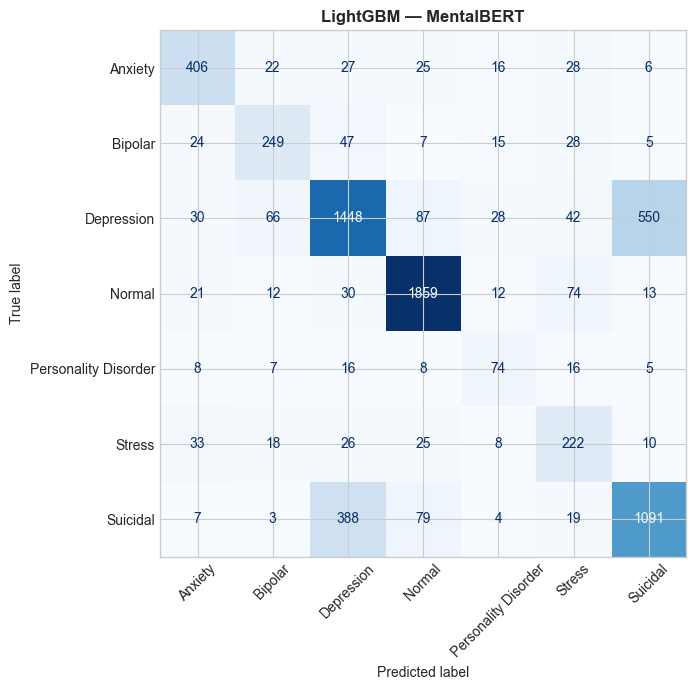

  CatBoost (MentalBERT)
  Macro F1:     0.6600
  Weighted F1:  0.7255
  Accuracy:     0.7243
  ROC AUC:      0.9445
  Suicidal R:   0.6958  [FAIL]  (target >= 0.9)
  Depression R: 0.6068  [FAIL]  (target >= 0.85)
  Stacking (MentalBERT)
  Macro F1:     0.6732
  Weighted F1:  0.7466
  Accuracy:     0.7512
  ROC AUC:      0.9441
  Suicidal R:   0.6493  [FAIL]  (target >= 0.9)
  Depression R: 0.7437  [FAIL]  (target >= 0.85)


In [25]:
if HAS_MENTAL:
    import lightgbm as lgb
    from catboost import CatBoostClassifier

    lgb_params_m = {**lgb_params, "num_leaves": 127, "colsample_bytree": 0.7}

    # LightGBM
    lgbm_m = lgb.LGBMClassifier(**lgb_params_m)
    lgbm_m.fit(mental_train_bal, y_mental_bal,
               eval_set=[(mental_val, y_val)],
               callbacks=[lgb.early_stopping(50, verbose=False),
                          lgb.log_evaluation(100)])
    trained["LightGBM (MentalBERT)"] = lgbm_m
    evaluate("LightGBM (MentalBERT)", y_test,
             lgbm_m.predict(mental_test),
             lgbm_m.predict_proba(mental_test))
    plot_cm(y_test, lgbm_m.predict(mental_test), "LightGBM — MentalBERT")

    # CatBoost
    cb_m = CatBoostClassifier(random_seed=SEED, iterations=400,
                               learning_rate=0.05, depth=6,
                               auto_class_weights="Balanced", verbose=0)
    cb_m.fit(mental_train_bal, y_mental_bal,
             eval_set=(mental_val, y_val), early_stopping_rounds=50)
    trained["CatBoost (MentalBERT)"] = cb_m
    evaluate("CatBoost (MentalBERT)", y_test,
             cb_m.predict(mental_test),
             cb_m.predict_proba(mental_test))

    # Stacking
    base_m = [
        ("lgbm", lgb.LGBMClassifier(**{**lgb_params_m, "n_estimators": 300})),
        ("rf",   RandomForestClassifier(n_estimators=200, class_weight=cw_dict,
                                        n_jobs=-1, random_state=SEED)),
        ("lr",   LogisticRegression(max_iter=500, C=1.0,
                                    class_weight="balanced", random_state=SEED)),
    ]
    stack_m = StackingClassifier(
        estimators=base_m,
        final_estimator=LogisticRegression(max_iter=300, C=0.5, random_state=SEED),
        cv=5, stack_method="predict_proba", n_jobs=-1
    )
    stack_m.fit(mental_train_bal, y_mental_bal)
    trained["Stacking (MentalBERT)"] = stack_m
    evaluate("Stacking (MentalBERT)", y_test,
             stack_m.predict(mental_test),
             stack_m.predict_proba(mental_test))

## 17. Neural Networks — MentalBERT 768d

In [26]:
if HAS_MENTAL:
    in_mental = mental_train_bal.shape[1]

    print("Training MLP Shallow (MentalBERT)...")
    mlp_sm = MLPShallow(in_mental, n_cls)
    mlp_sm = train_nn(mlp_sm, mental_train_bal, y_mental_bal, mental_val, y_val)
    trained["MLP Shallow (MentalBERT)"] = mlp_sm
    preds, probas = predict_nn(mlp_sm, mental_test)
    evaluate("MLP Shallow (MentalBERT)", y_test, preds, probas)

    print("\nTraining MLP Deep (MentalBERT)...")
    mlp_dm = MLPDeep(in_mental, n_cls)
    mlp_dm = train_nn(mlp_dm, mental_train_bal, y_mental_bal, mental_val, y_val)
    trained["MLP Deep (MentalBERT)"] = mlp_dm
    preds, probas = predict_nn(mlp_dm, mental_test)
    evaluate("MLP Deep (MentalBERT)", y_test, preds, probas)

    print("\nTraining 1D-CNN (MentalBERT)...")
    cnn_m = CNN1D(in_mental, n_cls)
    cnn_m = train_nn(cnn_m, mental_train_bal, y_mental_bal, mental_val, y_val)
    trained["1D-CNN (MentalBERT)"] = cnn_m
    preds, probas = predict_nn(cnn_m, mental_test)
    evaluate("1D-CNN (MentalBERT)", y_test, preds, probas)

Training MLP Shallow (MentalBERT)...
    Epoch   5 | val macro F1: 0.6621
    Epoch  10 | val macro F1: 0.6958
    Epoch  15 | val macro F1: 0.7106
    Epoch  20 | val macro F1: 0.7119
    Epoch  25 | val macro F1: 0.7142
    Early stop at epoch 29 | best val F1: 0.7201
  MLP Shallow (MentalBERT)
  Macro F1:     0.7287
  Weighted F1:  0.7725
  Accuracy:     0.7706
  ROC AUC:      0.9293
  Suicidal R:   0.7964  [FAIL]  (target >= 0.9)
  Depression R: 0.6379  [FAIL]  (target >= 0.85)

Training MLP Deep (MentalBERT)...
    Epoch   5 | val macro F1: 0.6748
    Epoch  10 | val macro F1: 0.6826
    Epoch  15 | val macro F1: 0.7012
    Early stop at epoch 16 | best val F1: 0.7052
  MLP Deep (MentalBERT)
  Macro F1:     0.7072
  Weighted F1:  0.7449
  Accuracy:     0.7457
  ROC AUC:      0.9076
  Suicidal R:   0.8397  [FAIL]  (target >= 0.9)
  Depression R: 0.5344  [FAIL]  (target >= 0.85)

Training 1D-CNN (MentalBERT)...
    Epoch   5 | val macro F1: 0.5400
    Epoch  10 | val macro F1: 0.585

## 18. Models — Combined Embeddings 1152d

[100]	valid_0's multi_logloss: 0.657908
[200]	valid_0's multi_logloss: 0.607277
  LightGBM (Combined)
  Macro F1:     0.7327
  Weighted F1:  0.7675
  Accuracy:     0.7675
  ROC AUC:      0.9593
  Suicidal R:   0.7146  [FAIL]  (target >= 0.9)
  Depression R: 0.6735  [FAIL]  (target >= 0.85)


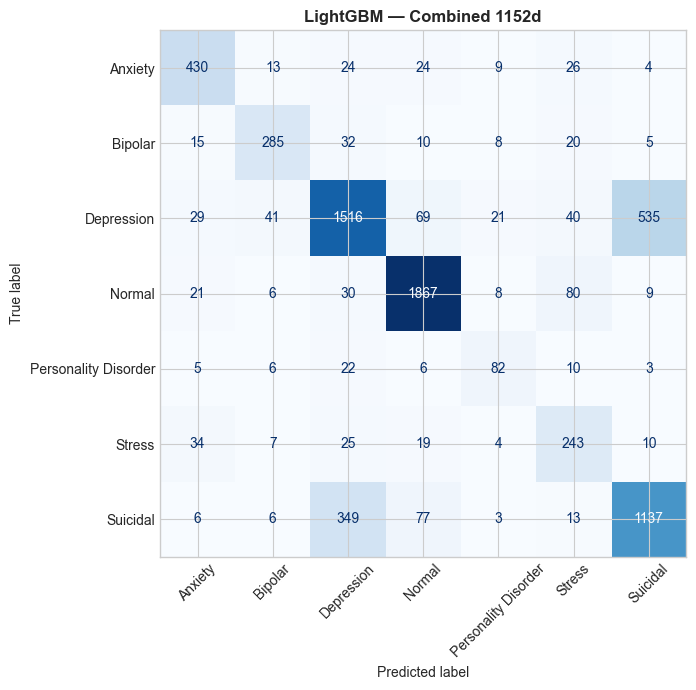

  CatBoost (Combined)
  Macro F1:     0.7028
  Weighted F1:  0.7501
  Accuracy:     0.7496
  ROC AUC:      0.9536
  Suicidal R:   0.7027  [FAIL]  (target >= 0.9)
  Depression R: 0.6455  [FAIL]  (target >= 0.85)
  Stacking (Combined)
  Macro F1:     0.7281
  Weighted F1:  0.7763
  Accuracy:     0.7794
  ROC AUC:      0.9560
  Suicidal R:   0.6813  [FAIL]  (target >= 0.9)
  Depression R: 0.7583  [FAIL]  (target >= 0.85)

Training MLP Shallow (Combined)...
    Epoch   5 | val macro F1: 0.7202
    Epoch  10 | val macro F1: 0.7420
    Epoch  15 | val macro F1: 0.7413
    Epoch  20 | val macro F1: 0.7559
    Epoch  25 | val macro F1: 0.7608
    Epoch  30 | val macro F1: 0.7608
  MLP Shallow (Combined)
  Macro F1:     0.7665
  Weighted F1:  0.7949
  Accuracy:     0.7942
  ROC AUC:      0.9409
  Suicidal R:   0.7964  [FAIL]  (target >= 0.9)
  Depression R: 0.6628  [FAIL]  (target >= 0.85)

Training MLP Deep (Combined)...
    Epoch   5 | val macro F1: 0.7051
    Epoch  10 | val macro F1: 0.7427

In [27]:
if HAS_COMBO:
    import lightgbm as lgb
    from catboost import CatBoostClassifier

    in_combo = combo_train_bal.shape[1]
    lgb_params_c = {**lgb_params, "num_leaves": 127, "colsample_bytree": 0.6}

    # LightGBM
    lgbm_c = lgb.LGBMClassifier(**lgb_params_c)
    lgbm_c.fit(combo_train_bal, y_combo_bal,
               eval_set=[(combo_val, y_val)],
               callbacks=[lgb.early_stopping(50, verbose=False),
                          lgb.log_evaluation(100)])
    trained["LightGBM (Combined)"] = lgbm_c
    evaluate("LightGBM (Combined)", y_test,
             lgbm_c.predict(combo_test),
             lgbm_c.predict_proba(combo_test))
    plot_cm(y_test, lgbm_c.predict(combo_test), "LightGBM — Combined 1152d")

    # CatBoost
    cb_c = CatBoostClassifier(random_seed=SEED, iterations=400,
                               learning_rate=0.05, depth=6,
                               auto_class_weights="Balanced", verbose=0)
    cb_c.fit(combo_train_bal, y_combo_bal,
             eval_set=(combo_val, y_val), early_stopping_rounds=50)
    trained["CatBoost (Combined)"] = cb_c
    evaluate("CatBoost (Combined)", y_test,
             cb_c.predict(combo_test),
             cb_c.predict_proba(combo_test))

    # Stacking
    base_c = [
        ("lgbm", lgb.LGBMClassifier(**{**lgb_params_c, "n_estimators": 300})),
        ("rf",   RandomForestClassifier(n_estimators=200, class_weight=cw_dict,
                                        n_jobs=-1, random_state=SEED)),
        ("lr",   LogisticRegression(max_iter=500, C=1.0,
                                    class_weight="balanced", random_state=SEED)),
    ]
    stack_c = StackingClassifier(
        estimators=base_c,
        final_estimator=LogisticRegression(max_iter=300, C=0.5, random_state=SEED),
        cv=5, stack_method="predict_proba", n_jobs=-1
    )
    stack_c.fit(combo_train_bal, y_combo_bal)
    trained["Stacking (Combined)"] = stack_c
    evaluate("Stacking (Combined)", y_test,
             stack_c.predict(combo_test),
             stack_c.predict_proba(combo_test))

    # Neural networks
    for arch_name, arch_cls in [("MLP Shallow", MLPShallow),
                                  ("MLP Deep",   MLPDeep),
                                  ("1D-CNN",     CNN1D)]:
        print(f"\nTraining {arch_name} (Combined)...")
        model = arch_cls(in_combo, n_cls)
        model = train_nn(model, combo_train_bal, y_combo_bal, combo_val, y_val)
        trained[f"{arch_name} (Combined)"] = model
        preds, probas = predict_nn(model, combo_test)
        evaluate(f"{arch_name} (Combined)", y_test, preds, probas)

## 19. Fine-tune MentalBERT — End-to-End (GPU)

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 18751.34it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: mental/mental-bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different tas

Epoch,Training Loss,Validation Loss,F1,Accuracy
1,0.598570,0.542931,0.774123,0.796935
2,0.406731,0.560024,0.804008,0.810326
3,0.286565,0.606124,0.810686,0.817780
4,0.166312,0.671207,0.824063,0.829652


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.90it/s]


  Fine-tune MentalBERT
  Macro F1:     0.8184
  Weighted F1:  0.8294
  Accuracy:     0.8287
  ROC AUC:      0.9749
  Suicidal R:   0.7951  [FAIL]  (target >= 0.9)
  Depression R: 0.7366  [FAIL]  (target >= 0.85)


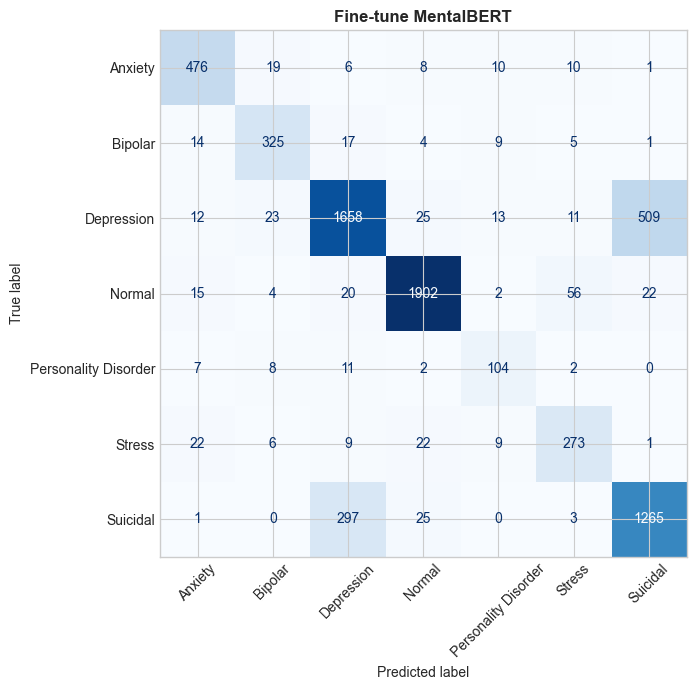

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.01it/s]

Fine-tuned model saved to ./mental_bert_final


In [29]:
if torch.cuda.is_available() and HAS_MENTAL:
    from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                               TrainingArguments, Trainer, DataCollatorWithPadding,
                               EarlyStoppingCallback)
    from datasets import Dataset as HFDataset

    FT_MODEL_NAME  = "mental/mental-bert-base-uncased"
    tok_ft         = AutoTokenizer.from_pretrained(FT_MODEL_NAME)

    def tokenize_ft(batch):
        return tok_ft(batch["text"], truncation=True, max_length=256)

    def make_hf_ds(texts, labels):
        ds = HFDataset.from_dict({
            "text":  texts.tolist(),
            "label": labels.tolist()
        })
        return ds.map(tokenize_ft, batched=True, remove_columns=["text"])

    hf_train = make_hf_ds(X_train_text, y_train)
    hf_val   = make_hf_ds(X_val_text,   y_val)
    hf_test  = make_hf_ds(X_test_text,  y_test)

    ft_model = AutoModelForSequenceClassification.from_pretrained(
        FT_MODEL_NAME, num_labels=len(CLASSES), ignore_mismatched_sizes=True
    )

    def compute_metrics_ft(pred):
        logits, labels = pred
        preds = logits.argmax(axis=1)
        return {
            "f1":       f1_score(labels, preds, average="macro", zero_division=0),
            "accuracy": accuracy_score(labels, preds),
        }

    class WeightedTrainer(Trainer):
        def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
            labels  = inputs.pop("labels")
            outputs = model(**inputs)
            loss    = nn.CrossEntropyLoss(weight=ce_weights)(outputs.logits, labels)
            return (loss, outputs) if return_outputs else loss

    training_args = TrainingArguments(
        output_dir               = "./mental_bert_ft",
        num_train_epochs         = 4,
        per_device_train_batch_size = 16,
        per_device_eval_batch_size  = 32,
        learning_rate            = 2e-5,
        warmup_ratio             = 0.1,
        weight_decay             = 0.01,
        eval_strategy            = "epoch",
        save_strategy            = "epoch",
        load_best_model_at_end   = True,
        metric_for_best_model    = "f1",
        greater_is_better        = True,
        fp16                     = True,
        report_to                = "none",
        logging_steps            = 100,
    )
    trainer = WeightedTrainer(
        model           = ft_model,
        args            = training_args,
        train_dataset   = hf_train,
        eval_dataset    = hf_val,
        processing_class= tok_ft,
        data_collator   = DataCollatorWithPadding(tok_ft),
        compute_metrics = compute_metrics_ft,
        callbacks       = [EarlyStoppingCallback(early_stopping_patience=2)],
    )
    trainer.train()

    preds_ft  = trainer.predict(hf_test)
    y_pred_ft = preds_ft.predictions.argmax(axis=1)
    proba_ft  = preds_ft.predictions
    proba_ft  = np.exp(proba_ft) / np.exp(proba_ft).sum(axis=1, keepdims=True)
    evaluate("Fine-tune MentalBERT", y_test, y_pred_ft, proba_ft)
    plot_cm(y_test, y_pred_ft, "Fine-tune MentalBERT")
    trainer.save_model("./mental_bert_final")
    print("Fine-tuned model saved to ./mental_bert_final")
else:
    print("Skipped — requires CUDA GPU")

## 20. Threshold Tuning — Recall-First Strategy

In [32]:
def tune_thresholds(proba_val, y_val, targets):
    """Find per-class thresholds that achieve target recall on validation set."""
    thresholds = {}
    for cls, target_rec in targets.items():
        if cls not in CLASSES:
            continue
        idx     = CLASSES.index(cls)
        best_thr = 0.5
        best_f1  = 0
        for thr in np.arange(0.10, 0.80, 0.01):
            pred_i   = (proba_val[:, idx] >= thr).astype(int)
            actual_i = (y_val == idx).astype(int)
            rec = recall_score(actual_i, pred_i, zero_division=0)
            f1  = f1_score(actual_i, pred_i, zero_division=0)
            if rec >= target_rec and f1 > best_f1:
                best_f1, best_thr = f1, thr
        thresholds[idx] = best_thr
        print(f"  {cls}: threshold = {best_thr:.2f}")
    return thresholds


def predict_thresholded(proba, thresholds):
    """Apply per-class thresholds; high-risk classes override argmax."""
    pred = proba.argmax(axis=1).copy()
    for cls_idx, thr in thresholds.items():
        mask = proba[:, cls_idx] >= thr
        pred[mask] = cls_idx
    return pred


# Apply to best available model
if leaderboard:
    # Recall-first: filter models that pass both thresholds, then sort by Macro F1
    # Замени строки выбора best_name:
    all_sorted = [k for k in sorted(leaderboard, key=lambda k: leaderboard[k]["Macro F1"], reverse=True)
              if k in trained]  # ← фильтр
    passed = {k: v for k, v in leaderboard.items()
          if v["Sui OK"] == "OK" and v["Dep OK"] == "OK" and k in trained}  # ← фильтр
    best_name  = sorted(passed, key=lambda k: leaderboard[k]["Macro F1"], reverse=True)[0] \
                 if passed else all_sorted[0]
    print(f"Best model for threshold tuning: {best_name}")

    best_model = trained[best_name]
    if hasattr(best_model, "predict_proba"):
        if "SBERT" in best_name and HAS_SBERT:
            proba_val_best  = best_model.predict_proba(emb_val)
            proba_test_best = best_model.predict_proba(emb_test)
        elif "MentalBERT" in best_name and HAS_MENTAL:
            proba_val_best  = best_model.predict_proba(mental_val)
            proba_test_best = best_model.predict_proba(mental_test)
        elif "Combined" in best_name and HAS_COMBO:
            proba_val_best  = best_model.predict_proba(combo_val)
            proba_test_best = best_model.predict_proba(combo_test)
        else:
            proba_val_best  = best_model.predict_proba(X_combo_val)
            proba_test_best = best_model.predict_proba(X_combo_test)

        print("\nTuning thresholds...")
        thresholds = tune_thresholds(proba_val_best, y_val, RECALL_TARGET)
        y_tuned    = predict_thresholded(proba_test_best, thresholds)
        evaluate(f"{best_name} + Thresholds", y_test, y_tuned, proba_test_best)
        plot_cm(y_test, y_tuned, f"{best_name} + Threshold Tuning")

Best model for threshold tuning: MLP Deep (Combined)


## 21. Binary Classifier — Depression vs Suicidal

In [33]:
DEP_IDX = CLASSES.index("Depression")
SUI_IDX = CLASSES.index("Suicidal")

# Filter only Depression and Suicidal samples
ds_tr = np.isin(y_train, [DEP_IDX, SUI_IDX])
ds_va = np.isin(y_val,   [DEP_IDX, SUI_IDX])
ds_te = np.isin(y_test,  [DEP_IDX, SUI_IDX])

y_bin_tr = (y_train[ds_tr] == SUI_IDX).astype(int)
y_bin_va = (y_val[ds_va]   == SUI_IDX).astype(int)
y_bin_te = (y_test[ds_te]  == SUI_IDX).astype(int)

# Suicide-specific features
SUICIDE_KEYWORDS = [
    "kill myself","end my life","want to die","commit suicide",
    "take my life","end it all","no reason to live","better off dead",
    "unalive","kms","sui","kys","can not go on","no way out","no point",
    "goodbye forever","last time","final","i will","i'm going to",
    "i have decided","i've decided","made up my mind","always","never",
    "nothing","nobody","worthless","hopeless","pointless","meaningless",
]
FUTURE_NEG  = ["never get better","never be happy","no future","no tomorrow"]
PASSIVE_DEP = ["i feel","i've been","so tired","exhausted",
               "empty inside","numb","can't sleep","crying"]

def suicide_feats(texts):
    feats = []
    for t in texts:
        tl    = t.lower()
        words = tl.split()
        n     = max(len(words), 1)
        feats.append([
            sum(1 for kw in SUICIDE_KEYWORDS if kw in tl),
            sum(1 for kw in FUTURE_NEG       if kw in tl),
            sum(1 for kw in PASSIVE_DEP      if kw in tl),
            sum(1 for w  in ["i will","i'm going","i have decided"] if w in tl),
            sum(1 for w  in ["last","final","goodbye","farewell","end","over"] if w in words),
            len(words),
        ])
    return np.array(feats, dtype=np.float32)

from scipy.sparse import csr_matrix, hstack as sp_hstack

tfidf_bin = TfidfVectorizer(max_features=8000, ngram_range=(1, 2),
                              sublinear_tf=True, min_df=2)
T_tr = tfidf_bin.fit_transform(X_train_text[ds_tr])
T_va = tfidf_bin.transform(X_val_text[ds_va])
T_te = tfidf_bin.transform(X_test_text[ds_te])

F_tr = suicide_feats(X_train_text[ds_tr])
F_va = suicide_feats(X_val_text[ds_va])
F_te = suicide_feats(X_test_text[ds_te])

X_bin_tr = sp_hstack([T_tr, csr_matrix(F_tr)])
X_bin_va = sp_hstack([T_va, csr_matrix(F_va)])
X_bin_te = sp_hstack([T_te, csr_matrix(F_te)])

smote_bin = SMOTE(random_state=SEED, k_neighbors=3)
X_bin_bal, y_bin_bal = smote_bin.fit_resample(X_bin_tr, y_bin_tr)

svm_bin = CalibratedClassifierCV(
    LinearSVC(C=0.5, class_weight={0:1, 1:2}, random_state=SEED, max_iter=2000), cv=5
)
svm_bin.fit(X_bin_bal, y_bin_bal)

lr_bin = LogisticRegression(C=0.3, class_weight={0:1, 1:2.5},
                             max_iter=500, random_state=SEED)
lr_bin.fit(X_bin_bal, y_bin_bal)

for name, model in [("SVM Binary (Dep/Sui)", svm_bin),
                     ("LR Binary (Dep/Sui)",  lr_bin)]:
    pred  = model.predict(X_bin_te)
    proba = model.predict_proba(X_bin_te)[:, 1]
    print(f"\n{name}")
    print(classification_report(y_bin_te, pred,
                                 target_names=["Depression", "Suicidal"]))

# Threshold tuning for binary classifier
proba_va_bin = svm_bin.predict_proba(X_bin_va)[:, 1]
best_thr_bin, best_f1_bin = 0.5, 0
for thr in np.arange(0.20, 0.80, 0.01):
    p   = (proba_va_bin >= thr).astype(int)
    rec = recall_score(y_bin_va, p, pos_label=1, zero_division=0)
    f1  = f1_score(y_bin_va, p, pos_label=1, zero_division=0)
    if rec >= 0.90 and f1 > best_f1_bin:
        best_f1_bin, best_thr_bin = f1, thr

print(f"\nOptimal threshold for Suicidal recall >= 0.90: {best_thr_bin:.2f}")
BIN_THRESHOLD = best_thr_bin
trained["SVM_binary_DepSui"] = svm_bin
trained["LR_binary_DepSui"]  = lr_bin


SVM Binary (Dep/Sui)
              precision    recall  f1-score   support

  Depression       0.79      0.78      0.79      2251
    Suicidal       0.70      0.72      0.71      1591

    accuracy                           0.75      3842
   macro avg       0.75      0.75      0.75      3842
weighted avg       0.75      0.75      0.75      3842


LR Binary (Dep/Sui)
              precision    recall  f1-score   support

  Depression       0.95      0.53      0.68      2251
    Suicidal       0.59      0.96      0.73      1591

    accuracy                           0.71      3842
   macro avg       0.77      0.75      0.71      3842
weighted avg       0.80      0.71      0.70      3842


Optimal threshold for Suicidal recall >= 0.90: 0.28


## 22. Final Leaderboard — Recall-First Ranking

LEADERBOARD — Recall-First Ranking
                         Macro F1 Weighted F1 Accuracy ROC AUC Suicidal R Depress R Sui OK Dep OK
Fine-tune MentalBERT       0.8184      0.8294   0.8287  0.9749     0.7951    0.7366   FAIL   FAIL
MLP Deep (Combined)         0.772      0.7963   0.7962  0.9267     0.8165     0.653   FAIL   FAIL
MLP Shallow (Combined)     0.7665      0.7949   0.7942  0.9409     0.7964    0.6628   FAIL   FAIL
LightGBM (Combined)        0.7327      0.7675   0.7675  0.9593     0.7146    0.6735   FAIL   FAIL
SVM Tuned (TF-IDF)         0.7287      0.7692   0.7732  0.9561     0.6776    0.7499   FAIL   FAIL
MLP Shallow (MentalBERT)   0.7287      0.7725   0.7706  0.9293     0.7964    0.6379   FAIL   FAIL
Stacking (Combined)        0.7281      0.7763   0.7794   0.956     0.6813    0.7583   FAIL   FAIL
LinearSVM (TF-IDF)         0.7242      0.7641   0.7684  0.9545     0.6744     0.745   FAIL   FAIL
MLP Deep (SBERT)           0.7154      0.7505   0.7517  0.9105     0.7737    0.5993

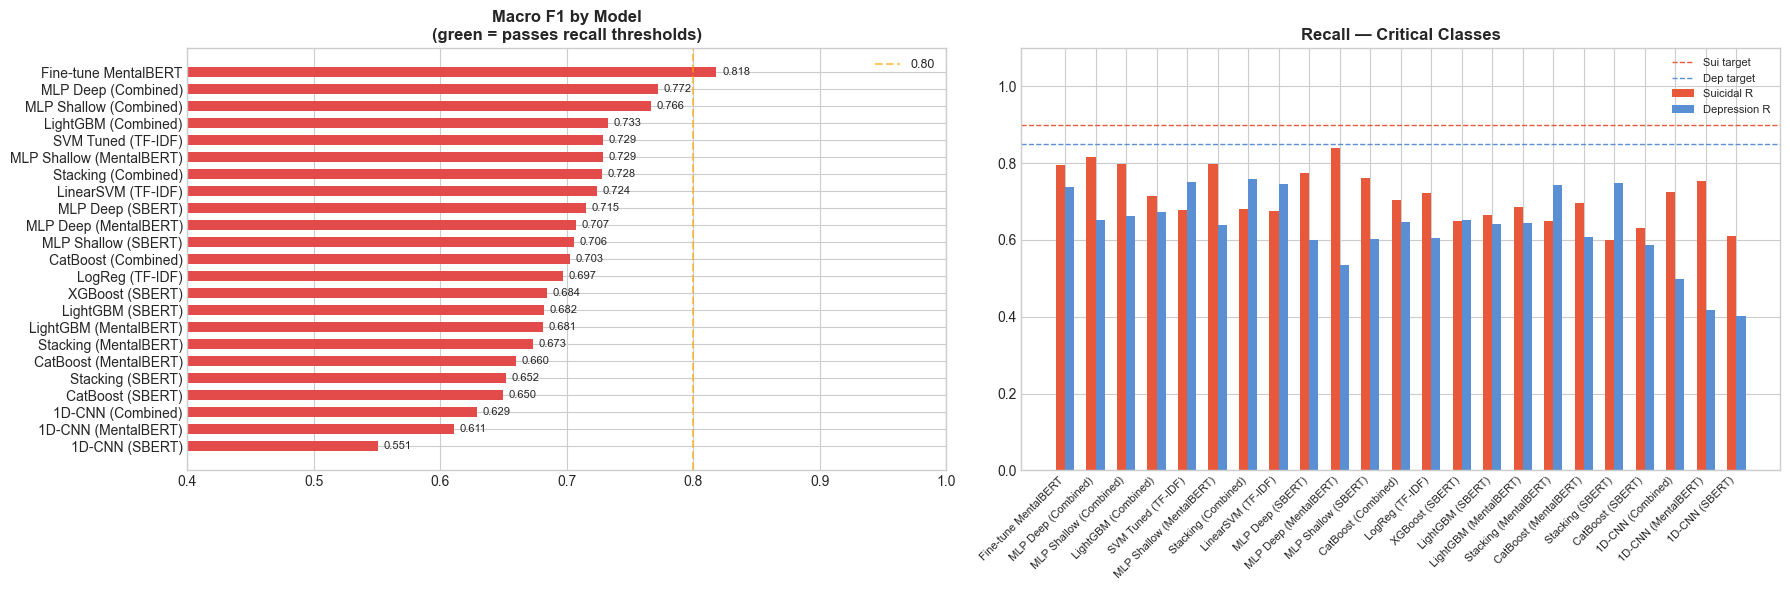


Best model: Fine-tune MentalBERT


In [34]:
if leaderboard:
    board = pd.DataFrame(leaderboard).T

    # Recall-first sort: models passing both thresholds first, then by Macro F1
    board["passed"] = (board["Sui OK"] == "OK") & (board["Dep OK"] == "OK")
    board = board.sort_values(["passed", "Macro F1"], ascending=[False, False])

    print("=" * 80)
    print("LEADERBOARD — Recall-First Ranking")
    print("=" * 80)
    print(board[["Macro F1","Weighted F1","Accuracy","ROC AUC",
                 "Suicidal R","Depress R","Sui OK","Dep OK"]].to_string())

    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    vals   = board["Macro F1"].sort_values()
    colors = ["#1D9E75" if ok else "#E24B4A"
              for ok in board.loc[vals.index, "passed"]]
    bars   = axes[0].barh(vals.index, vals.values, color=colors, height=0.6)
    axes[0].bar_label(bars, fmt="%.3f", padding=4, fontsize=8)
    axes[0].set_xlim(0.4, 1.0)
    axes[0].set_title("Macro F1 by Model\n(green = passes recall thresholds)",
                      fontweight="bold")
    axes[0].axvline(0.80, color="orange", ls="--", alpha=0.6, label="0.80")
    axes[0].legend(fontsize=9)

    x = np.arange(len(board))
    w = 0.3
    axes[1].bar(x,       board["Suicidal R"].values, w, label="Suicidal R",  color="#E8593C")
    axes[1].bar(x + w,   board["Depress R"].values,  w, label="Depression R",color="#5A8FD4")
    axes[1].axhline(0.90, color="#E8593C", ls="--", lw=1, label="Sui target")
    axes[1].axhline(0.85, color="#5A8FD4", ls="--", lw=1, label="Dep target")
    axes[1].set_xticks(x + w/2)
    axes[1].set_xticklabels(board.index, rotation=45, ha="right", fontsize=8)
    axes[1].set_ylim(0, 1.1)
    axes[1].legend(fontsize=8)
    axes[1].set_title("Recall — Critical Classes", fontweight="bold")

    plt.tight_layout()
    plt.savefig("leaderboard.png", dpi=150, bbox_inches="tight")
    plt.show()

    best_name = board.index[0]
    print(f"\nBest model: {best_name}")

## 23. SHAP Feature Importance

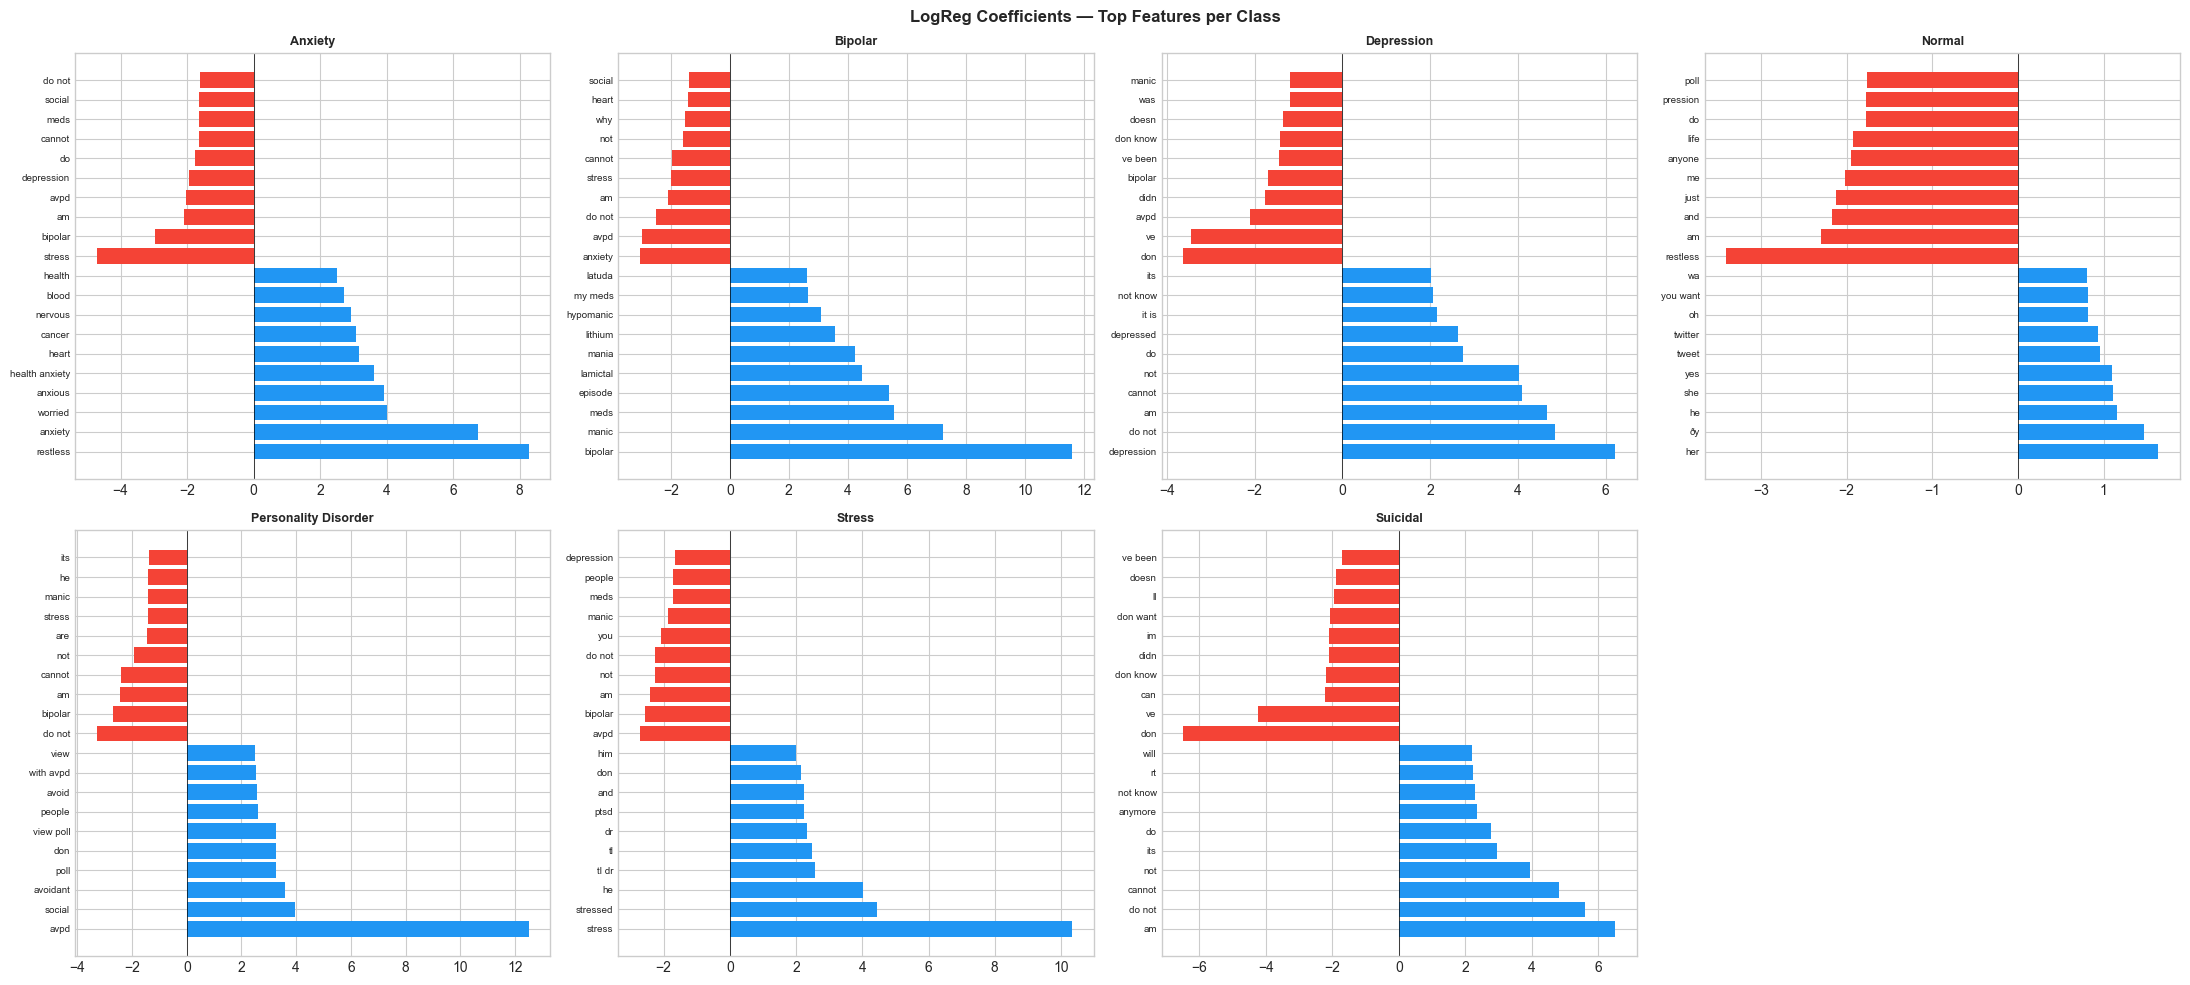

In [35]:
try:
    import shap

    if "LogReg (TF-IDF)" in trained:
        lr_shap  = trained["LogReg (TF-IDF)"]
        coefs    = lr_shap.coef_
        feat_names_all = list(tfidf.get_feature_names_out()) + stat_feats

        fig, axes = plt.subplots(2, 4, figsize=(22, 10))
        axes = axes.flatten()
        for i, lbl in enumerate(CLASSES):
            c       = coefs[i][:len(tfidf.get_feature_names_out())]
            top_pos = c.argsort()[-10:][::-1]
            top_neg = c.argsort()[:10]
            top_idx = np.concatenate([top_pos, top_neg])
            vals    = c[top_idx]
            names   = [feat_names_all[j] for j in top_idx]
            colors  = ["#2196F3" if v > 0 else "#F44336" for v in vals]
            axes[i].barh(range(len(names)), vals, color=colors)
            axes[i].set_yticks(range(len(names)))
            axes[i].set_yticklabels(names, fontsize=7)
            axes[i].set_title(lbl, fontweight="bold", fontsize=9)
            axes[i].axvline(0, color="black", lw=0.5)
        for j in range(len(CLASSES), 8):
            axes[j].axis("off")
        plt.suptitle("LogReg Coefficients — Top Features per Class",
                     fontweight="bold", fontsize=12)
        plt.tight_layout()
        plt.show()

except ImportError:
    print("SHAP not installed. pip install shap")

## 24. Save Best Model & All Artifacts

In [36]:
import re as _re
os.makedirs("saved_models", exist_ok=True)

# Save all sklearn/boosting models
for name, model in trained.items():
    safe = _re.sub(r"[^\w]", "_", name)[:40]
    path = f"saved_models/model_{safe}.pkl"
    try:
        joblib.dump(model, path)
        print(f"  Saved: {path}")
    except Exception as e:
        print(f"  Skip {name}: {e}")

# Save preprocessing artifacts
joblib.dump(le,          "saved_models/label_encoder.pkl")
joblib.dump(tfidf,       "saved_models/tfidf.pkl")
joblib.dump(scaler,      "saved_models/scaler.pkl")
joblib.dump(tfidf_bin,   "saved_models/tfidf_binary.pkl")

# Save leaderboard
if leaderboard:
    board = pd.DataFrame(leaderboard).T.sort_values("Macro F1", ascending=False)
    board.to_csv("saved_models/leaderboard.csv")
    print(f"\nLeaderboard saved. Best: {board.index[0]}")

# Save PyTorch neural networks
for name, model in trained.items():
    if isinstance(model, nn.Module):
        safe = _re.sub(r"[^\w]", "_", name)[:40]
        torch.save(model.state_dict(), f"saved_models/nn_{safe}.pt")
        print(f"  Saved NN: nn_{safe}.pt")

# Save metadata for Streamlit
import json
meta = {
    "classes":        CLASSES,
    "best_model":     board.index[0] if leaderboard else "unknown",
    "bin_threshold":  float(BIN_THRESHOLD),
    "recall_targets": RECALL_TARGET,
    "num_feat_cols":  num_feat_cols,
}
with open("saved_models/meta.json", "w") as f:
    json.dump(meta, f, indent=2)
print("\nmeta.json saved — ready for Streamlit")

  Saved: saved_models/model_LogReg__TF_IDF_.pkl
  Saved: saved_models/model_LinearSVM__TF_IDF_.pkl
  Saved: saved_models/model_SVM_Tuned__TF_IDF_.pkl
  Saved: saved_models/model_LightGBM__SBERT_.pkl
  Saved: saved_models/model_CatBoost__SBERT_.pkl
  Saved: saved_models/model_XGBoost__SBERT_.pkl
  Saved: saved_models/model_Stacking__SBERT_.pkl
  Saved: saved_models/model_MLP_Shallow__SBERT_.pkl
  Saved: saved_models/model_MLP_Deep__SBERT_.pkl
  Saved: saved_models/model_1D_CNN__SBERT_.pkl
  Saved: saved_models/model_LightGBM__MentalBERT_.pkl
  Saved: saved_models/model_CatBoost__MentalBERT_.pkl
  Saved: saved_models/model_Stacking__MentalBERT_.pkl
  Saved: saved_models/model_MLP_Shallow__MentalBERT_.pkl
  Saved: saved_models/model_MLP_Deep__MentalBERT_.pkl
  Saved: saved_models/model_1D_CNN__MentalBERT_.pkl
  Saved: saved_models/model_LightGBM__Combined_.pkl
  Saved: saved_models/model_CatBoost__Combined_.pkl
  Saved: saved_models/model_Stacking__Combined_.pkl
  Saved: saved_models/mode

## 25. Inference Function — predict_risk()

In [39]:
def predict_risk(text):
    """Full inference pipeline for a single text input."""
    t = text
    for fn in [clean_reddit, clean_html, norm_unicode, clean_chars]:
        t = fn(t)

    # Choose best available model
    if leaderboard:
        best = sorted(
            [k for k in leaderboard
             if leaderboard[k]["Sui OK"] == "OK" and k in trained],
            key=lambda k: leaderboard[k]["Macro F1"], reverse=True
        )
        best_name = (best[0] if best else
                     max((k for k in leaderboard if k in trained),
                         key=lambda k: leaderboard[k]["Macro F1"]))
    else:
        best_name = "SVM Tuned (TF-IDF)"

    model = trained[best_name]

    # ── Получаем эмбеддинги ──────────────────────────────────────────────
    if HAS_SBERT and "SBERT" in best_name:
        X = sbert.encode([t], convert_to_numpy=True, normalize_embeddings=True)
    elif HAS_MENTAL and "MentalBERT" in best_name:
        X = encode_mental(np.array([t]))
    elif HAS_COMBO and "Combined" in best_name:
        e_s = sbert.encode([t], convert_to_numpy=True, normalize_embeddings=True)
        e_m = encode_mental(np.array([t]))
        X   = np.hstack([e_s, e_m])
    else:
        X = None

    # ── Инференс ─────────────────────────────────────────────────────────
    if isinstance(model, nn.Module):                  # ← PyTorch (MLP, CNN)
        _, probas = predict_nn(model, X)
        proba = probas[0]
    elif X is not None:                               # ← sklearn с эмбеддингами
        proba = model.predict_proba(X)[0]
    else:                                             # ← TF-IDF baseline
        t_lower = t.lower()
        X_tf    = tfidf.transform([t_lower])
        num     = scaler.transform(np.zeros((1, len(num_feat_cols))))
        X_inp   = sparse.hstack([X_tf, sparse.csr_matrix(num)])
        proba   = model.predict_proba(X_inp)[0]

    pred_idx = int(proba.argmax())
    label    = CLASSES[pred_idx]

    risk = ("HIGH"   if label in ["Suicidal", "Depression"]
            else "MEDIUM" if label in ["Anxiety","Bipolar","Stress","Personality Disorder"]
            else "LOW")

    print(f"Text:   {text[:80]}")
    print(f"Class:  {label}  |  Risk: {risk}  |  Model: {best_name}")
    print("Probabilities:")
    for i in np.argsort(proba)[::-1][:4]:
        bar  = "█" * int(proba[i] * 30)
        mark = " <- predicted" if i == pred_idx else ""
        print(f"  {CLASSES[i]:25s} {proba[i]:.3f}  {bar}{mark}")
    return label, risk, proba


# Quick test
predict_risk("I've been thinking about ending everything. There's no point anymore.")
print()
predict_risk("Feeling great today, went for a run and had a good breakfast.")
print()
predict_risk("I can't stop worrying about everything. My heart races all the time.")

Text:   I've been thinking about ending everything. There's no point anymore.
Class:  Depression  |  Risk: HIGH  |  Model: MLP Deep (Combined)
Probabilities:
  Depression                0.559  ████████████████ <- predicted
  Personality Disorder      0.211  ██████
  Suicidal                  0.071  ██
  Bipolar                   0.067  ██

Text:   Feeling great today, went for a run and had a good breakfast.
Class:  Normal  |  Risk: LOW  |  Model: MLP Deep (Combined)
Probabilities:
  Normal                    0.677  ████████████████████ <- predicted
  Personality Disorder      0.148  ████
  Bipolar                   0.056  █
  Stress                    0.054  █

Text:   I can't stop worrying about everything. My heart races all the time.
Class:  Anxiety  |  Risk: MEDIUM  |  Model: MLP Deep (Combined)
Probabilities:
  Anxiety                   0.897  ██████████████████████████ <- predicted
  Personality Disorder      0.053  █
  Stress                    0.021  
  Bipolar                

(np.str_('Anxiety'),
 'MEDIUM',
 array([0.89691335, 0.01816214, 0.0038559 , 0.00328979, 0.05337271,
        0.02057718, 0.00382887], dtype=float32))